<a href="https://colab.research.google.com/github/aidaaarf/DATA/blob/main/Cleansing_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving raw_transaction_log_1000.csv to raw_transaction_log_1000.csv


In [2]:
import pandas as pd

df = pd.read_csv('raw_transaction_log_1000.csv')
df.head()

,timestamp,user_id,action,amount,status,ip_address,device
0,2026-01-01 22:05:06,1002.0,TRANSFER,NaN,FAILED,UNKNOWN,Web
1,2026-01-02 04:40:06,1067.0,TRANSFER,855413,FAILED,UNKNOWN,Web
2,2026-01-01 18:26:39,1089.0,LOGIN,NaN,FAILED,192.168.1.19,Android
3,2026-01-01 17:11:16,1035.0,TRANSFER,111364,SUCCESS,UNKNOWN,iOS
4,2026-01-02 05:59:15,1100.0,LOGIN,NaN,SUCCESS,NaN,Android


In [3]:
# convert timestamp
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

# convert amount
df['amount'] = pd.to_numeric(df['amount'], errors='coerce')

# remove invalid rows
df = df.dropna(subset=['user_id', 'timestamp'])

# remove invalid transfer
df = df[~((df['action'] == 'TRANSFER') & (df['amount'] <= 0))]

# fill missing IP
df['ip_address'] = df['ip_address'].fillna('UNKNOWN')

df.head()

,timestamp,user_id,action,amount,status,ip_address,device
0,2026-01-01 22:05:06,1002.0,TRANSFER,NaN,FAILED,UNKNOWN,Web
1,2026-01-02 04:40:06,1067.0,TRANSFER,855413.0,FAILED,UNKNOWN,Web
2,2026-01-01 18:26:39,1089.0,LOGIN,NaN,FAILED,192.168.1.19,Android
3,2026-01-01 17:11:16,1035.0,TRANSFER,111364.0,SUCCESS,UNKNOWN,iOS
4,2026-01-02 05:59:15,1100.0,LOGIN,NaN,SUCCESS,UNKNOWN,Android


In [4]:
summary = df.groupby('action').agg({
    'user_id': 'count',
    'amount': 'sum'
})

summary

,user_id,amount
action,,
LOGIN,432,0.0
TRANSFER,409,107284704.0


# VISUALISASI

**Transaction Volume Over Time**   

👉 Insight:
- jam sibuk sistem
- pola user behavior

<Axes: xlabel='hour'>

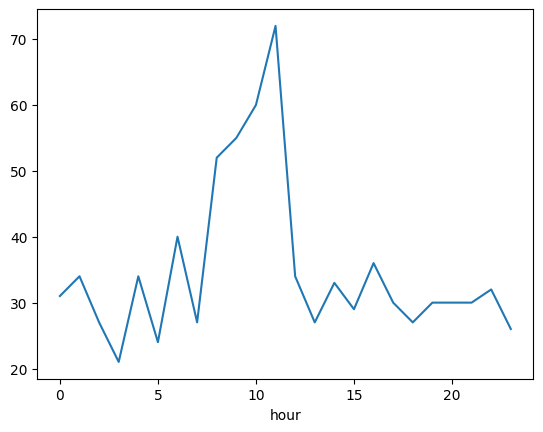

In [5]:
df['hour'] = df['timestamp'].dt.hour

df.groupby('hour').size().plot(kind='line')

**Success vs Failed Rate**

👉 Insight:
- error rate sistem
- indikasi reliability

<Axes: xlabel='status'>

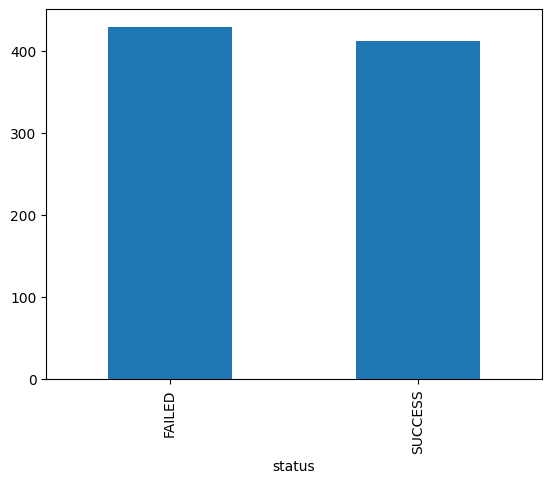

In [6]:
df['status'].value_counts().plot(kind='bar')

**Device Distribution**

👉 Insight:
- user dominan pakai apa
- bisa relate ke performa per device

<Axes: ylabel='count'>

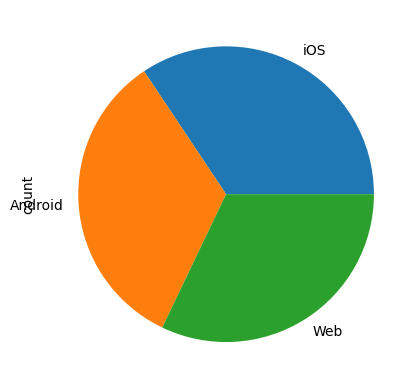

In [7]:
df['device'].value_counts().plot(kind='pie')

**Transfer Amount Distribution**

👉 Insight:
- pola transaksi normal
- outlier / transaksi aneh

<Axes: ylabel='Frequency'>

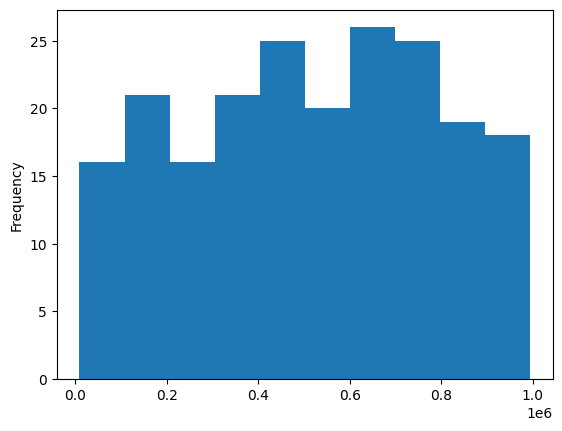

In [8]:
df[df['action']=='TRANSFER']['amount'].plot(kind='hist')

# ANOMALY DETECTION

**Transaksi Tanpa Login**

👉 Insight:

kemungkinan bug / security issue

In [16]:
# user yang transfer tapi tidak login sebelumnya

**Duplicate Transaction**

👉 Insight:

potensi double processing

In [10]:
df.duplicated().sum()

np.int64(0)

**Abnormal Amount**

👉 Insight:

fraud / sistem error

In [11]:
df[df['amount'] > 1000000]

,timestamp,user_id,action,amount,status,ip_address,device,hour


# System Performance Analysis

**Estimasi Load Sistem**

👉 insight:

mengidentifikasi peak load system

In [12]:
df.groupby('hour').size()

,0
hour,
0,31
1,34
2,27
3,21
4,34
5,24
6,40
7,27
8,52


**Error Rate per Time**

👉 Insight:

kapan sistem paling sering error

In [13]:
df.groupby('hour')['status'].apply(lambda x: (x=='FAILED').mean())

,status
hour,
0,0.516129
1,0.352941
2,0.481481
3,0.380952
4,0.470588
5,0.541667
6,0.700000
7,0.407407
8,0.403846


# Experimental Analysis

In [14]:
# bandingkan performa Android vs iOS
df.groupby('device')['status'].apply(lambda x: (x=='FAILED').mean())

,status
device,
Android,0.514184
Web,0.525926
iOS,0.491349


👉 Insight:

device mana lebih sering error

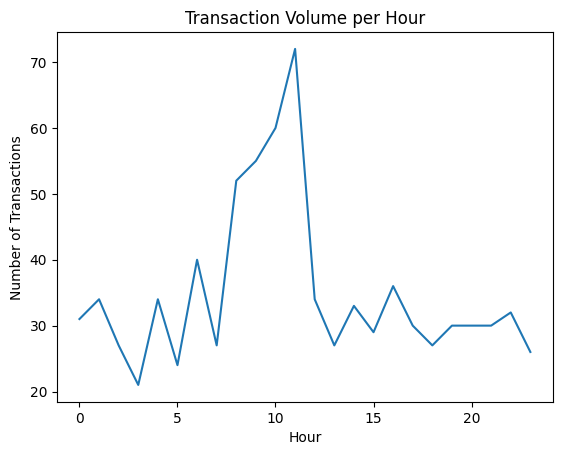

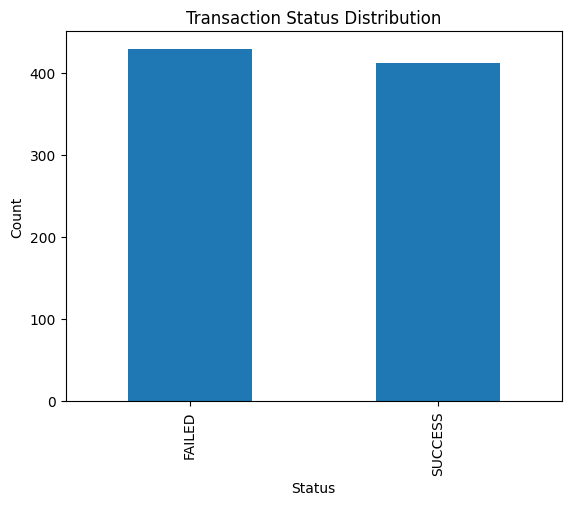

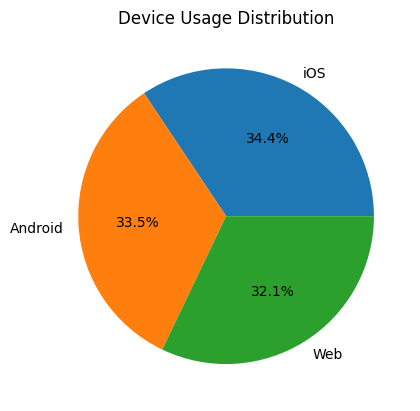

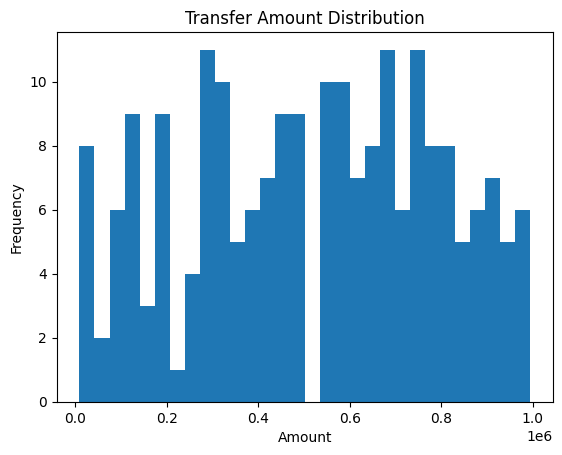

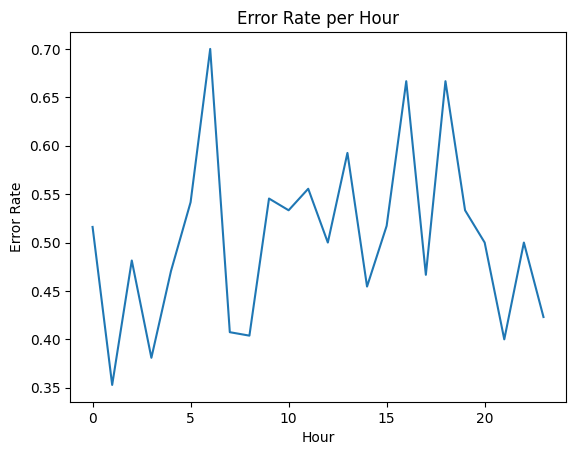

In [15]:
import matplotlib.pyplot as plt

# ===== 1. TRANSACTION VOLUME PER JAM =====
df['hour'] = df['timestamp'].dt.hour

plt.figure()
df.groupby('hour').size().plot()
plt.title("Transaction Volume per Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Transactions")
plt.show()


# ===== 2. SUCCESS vs FAILED =====
plt.figure()
df['status'].value_counts().plot(kind='bar')
plt.title("Transaction Status Distribution")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()


# ===== 3. DEVICE DISTRIBUTION =====
plt.figure()
df['device'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Device Usage Distribution")
plt.ylabel("")
plt.show()


# ===== 4. TRANSFER AMOUNT DISTRIBUTION =====
plt.figure()
df[df['action']=='TRANSFER']['amount'].plot(kind='hist', bins=30)
plt.title("Transfer Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()


# ===== 5. ERROR RATE PER JAM =====
error_rate = df.groupby('hour')['status'].apply(lambda x: (x=='FAILED').mean())

plt.figure()
error_rate.plot()
plt.title("Error Rate per Hour")
plt.xlabel("Hour")
plt.ylabel("Error Rate")
plt.show()